In [16]:
import pandas as pd
import matplotlib.pyplot as plt

In [17]:
csv_path = '~/smt-napsat-conflicts-fixed.csv.xz'
df = pd.read_csv(csv_path, compression="xz")
df.rename(columns=lambda x: x.strip(), inplace=True)
#df.columns = ['experiment', "unassign-rscb", "unassign-ncb", "unassign-gb", "conflict-rscb", "conflict-ncb", "conflict-gb", "-rscb-avg", "-ncb-avg", "-gb-avg"]
#df.columns = ['experiment', "unassign-rscb", "unassign-ncb", "unassign-gb", "conflict-rscb", "conflict-ncb", "conflict-gb"]
df.set_index(df.columns[0], inplace=True)
df.head()

,unassign-rscb,unassign-ncb,unassign-gb,conflict-rscb,conflict-ncb,conflict-gb,avg-size-rscb,avg-size-ncb,avg-size-gb,actual-rscb,actual-ncb,actual-gb
name,,,,,,,,,,,,
iso_brn766.smt2.stdout.10.xz,115,116,12,2,2,1,21.5,21.5,18.0,50,51,12
iso_brn_repgen003.smt2.stdout.1287.xz,9,9,9,1,1,1,17.0,17.0,17.0,9,9,9
cut_lemma_03_010.smt2.slack.smt2.stdout.45.xz,3,21,3,1,1,1,13.0,13.0,13.0,3,21,3
problem__006.smt2.stdout.198.xz,17,17,11,1,1,1,12.0,12.0,12.0,17,17,11
cut_lemma_01_010.smt2.slack.smt2.stdout.10.xz,2,2,2,1,1,1,13.0,13.0,13.0,2,2,2


In [18]:
df = df[["actual-rscb", "actual-ncb", "actual-gb", "conflict-rscb", "conflict-ncb", "conflict-gb"]]
df.columns = ["unassign-rscb", "unassign-ncb", "unassign-gb", "conflict-rscb", "conflict-ncb", "conflict-gb"]
df.head()

,unassign-rscb,unassign-ncb,unassign-gb,conflict-rscb,conflict-ncb,conflict-gb
name,,,,,,
iso_brn766.smt2.stdout.10.xz,50,51,12,2,2,1
iso_brn_repgen003.smt2.stdout.1287.xz,9,9,9,1,1,1
cut_lemma_03_010.smt2.slack.smt2.stdout.45.xz,3,21,3,1,1,1
problem__006.smt2.stdout.198.xz,17,17,11,1,1,1
cut_lemma_01_010.smt2.slack.smt2.stdout.10.xz,2,2,2,1,1,1


In [19]:
print(len(df))

# Calculate comparisons between "unassign-ncb" and "unassign-gb"
ncb_gt_gb = (df["unassign-ncb"] > df["unassign-gb"]).sum()
ncb_lt_gb = (df["unassign-ncb"] < df["unassign-gb"]).sum()
ncb_eq_gb = (df["unassign-ncb"] == df["unassign-gb"]).sum()
print(f"-ncb > -gb: {ncb_gt_gb}")
print(f"-ncb < -gb: {ncb_lt_gb}")
print(f"-ncb == -gb: {ncb_eq_gb}")

# Calculate the average difference between "unassign-ncb" and "unassign-gb"
avg_diff = (df["unassign-ncb"] - df["unassign-gb"]).mean()
print(f"Average difference (-ncb - -gb): {avg_diff}")

2909120
-ncb > -gb: 1459003
-ncb < -gb: 773328
-ncb == -gb: 676789
Average difference (-ncb - -gb): 17.84215398471015


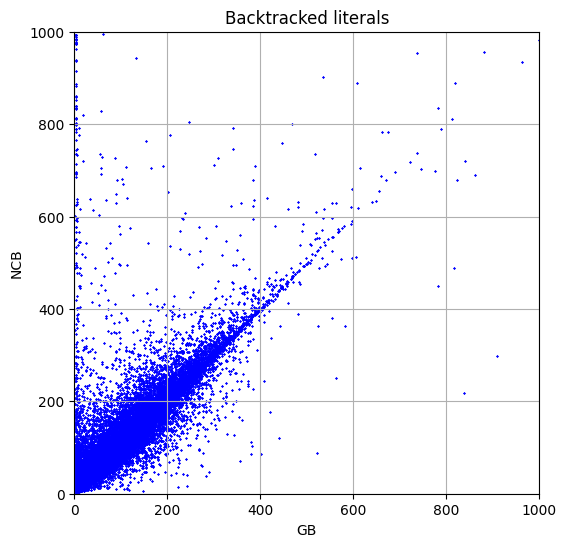

In [20]:
N = 30000
plot_sample = df.sample(n=N, random_state=4) if len(df) > N else df
plt.figure(figsize=(6, 6))
plt.scatter(plot_sample["unassign-gb"], plot_sample["unassign-ncb"], alpha=1, s=0.5, c='blue', marker='x')
plt.xlabel("GB")
plt.ylabel("NCB")
plt.xlim(0,1000)
plt.ylim(0,1000)
plt.title("Backtracked literals")
plt.grid(True)
plt.savefig("/home/tom/smt-napsat-eval.pdf")
plt.savefig("/home/tom/smt-napsat-eval.png")
plt.show()

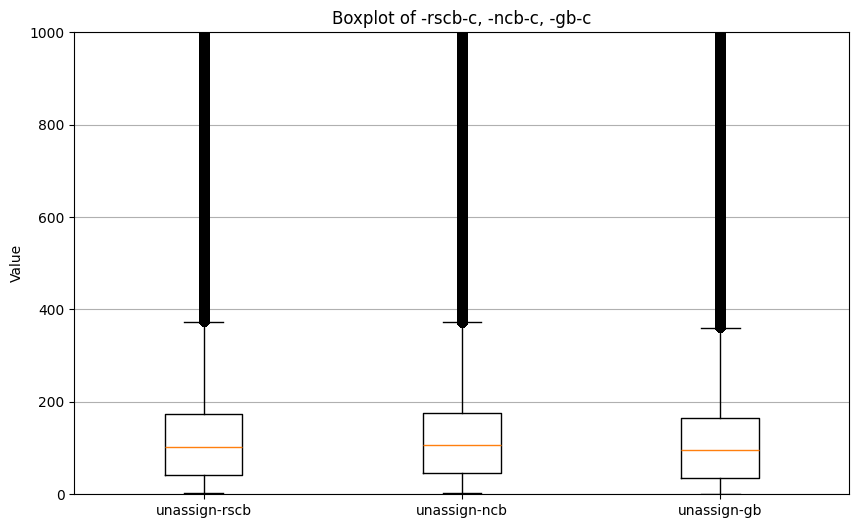

In [21]:

# Boxplot of the last three columns: -rscb-c, -ncb-c, -gb-c
plt.figure(figsize=(10, 6))
plt.boxplot([df["unassign-rscb"], df["unassign-ncb"], df["unassign-gb"]], tick_labels=["unassign-rscb", "unassign-ncb", "unassign-gb"])
plt.ylabel("Value")
plt.ylim(0, 1000)
plt.title("Boxplot of -rscb-c, -ncb-c, -gb-c")
plt.grid(True, axis='y')
plt.show()

In [22]:

# Print the average of the last three columns
avg_rscb_c = df["conflict-rscb"].mean()
avg_ncb_c = df["conflict-ncb"].mean()
avg_gb_c = df["conflict-gb"].mean()
print(f"Average -rscb-c: {avg_rscb_c}")
print(f"Average -ncb-c: {avg_ncb_c}")
print(f"Average -gb-c: {avg_gb_c}")

Average -rscb-c: 1.543680563194368
Average -ncb-c: 1.4567037454625453
Average -gb-c: 2.015014506104939


## Clustering

In [23]:
tiny = df[df["unassign-ncb"] + df["unassign-gb"] <= 10]
small = df[(df["unassign-ncb"] + df["unassign-gb"] > 10) & (df["unassign-ncb"] + df["unassign-gb"] <= 50)]
medium = df[(df["unassign-ncb"] + df["unassign-gb"] > 50) & (df["unassign-ncb"] + df["unassign-gb"] <= 100)]
big = df[(df["unassign-ncb"] + df["unassign-gb"] > 100) & (df["unassign-ncb"] + df["unassign-gb"] <= 500)]
huge = df[df["unassign-ncb"] + df["unassign-gb"] > 500]

dfs = [tiny, small, medium, big, huge]
names = ["tiny", "small", "medium", "big", "huge"]

In [24]:
print("## Count")
print ("Total:", len(df))
for i, ddf in enumerate(dfs):
    print(names[i], len(ddf))

## Count
Total: 2909120
tiny 67274
small 411097
medium 339571
big 1847692
huge 243486


In [25]:
print("## Ratios")
for i, ddf in enumerate(dfs):
    ncb_gt_gb = (ddf["unassign-ncb"] > ddf["unassign-gb"]).sum()
    ncb_lt_gb = (ddf["unassign-ncb"] < ddf["unassign-gb"]).sum()
    ncb_eq_gb = (ddf["unassign-ncb"] == ddf["unassign-gb"]).sum()
    print(f"{names[i]}: -ncb > -gb: {round(ncb_gt_gb*100/len(ddf),2)}%, -ncb < -gb: {round(ncb_lt_gb*100/len(ddf),2)}%, -ncb == -gb: {round(ncb_eq_gb*100/len(ddf),2)}%")

## Ratios
tiny: -ncb > -gb: 46.81%, -ncb < -gb: 7.7%, -ncb == -gb: 45.49%
small: -ncb > -gb: 49.53%, -ncb < -gb: 16.52%, -ncb == -gb: 33.94%
medium: -ncb > -gb: 52.2%, -ncb < -gb: 23.41%, -ncb == -gb: 24.39%
big: -ncb > -gb: 48.95%, -ncb < -gb: 30.33%, -ncb == -gb: 20.72%
huge: -ncb > -gb: 58.38%, -ncb < -gb: 24.79%, -ncb == -gb: 16.83%


In [26]:
df_tiny = df[df["unassign-gb"] + df["unassign-ncb"] <= 10]
df_small = df[(df["unassign-gb"] + df["unassign-ncb"] > 10) & (df["unassign-gb"] + df["unassign-ncb"] <= 50)]
df_med = df[(df["unassign-gb"] + df["unassign-ncb"] > 50) & (df["unassign-gb"] + df["unassign-ncb"] <= 100)]
df_big = df[(df["unassign-gb"] + df["unassign-ncb"] > 100) & (df["unassign-gb"] + df["unassign-ncb"] <= 500)]
df_huge = df[df["unassign-gb"] + df["unassign-ncb"] > 500]

dfs = [df_tiny, df_small, df_med, df_big, df_huge]
names = ["Tiny", "Small", "Medium", "Big", "Huge"]

In [27]:
print("## Average Differences (-ncb - -gb)")
for i, ddf in enumerate(dfs):
    avg_diff = round((ddf["unassign-ncb"] - ddf["unassign-gb"]).mean(), 2)
    std_diff = round((ddf["unassign-ncb"] - ddf["unassign-gb"]).std(), 2)
    print(f"{names[i]}: {avg_diff} \\x {std_diff}")


## Average Differences (-ncb - -gb)
Tiny: 1.18 \x 1.96
Small: 3.98 \x 8.45
Medium: 9.42 \x 20.29
Big: 11.43 \x 42.46
Huge: 106.28 \x 401.14


In [28]:
print("## Average unassignments")
for i, ddf in enumerate(dfs):
    avg_ncb = round(ddf["unassign-ncb"].mean(), 2)
    std_ncb = round(ddf["unassign-ncb"].std(), 2)
    avg_gb = round(ddf["unassign-gb"].mean(), 2)
    std_gb = round(ddf["unassign-gb"].std(), 2)
    print(f"{names[i]}: {avg_ncb} \\x {std_ncb}, -gb: mean={avg_gb} \\x {std_gb}")

## Average unassignments
Tiny: 4.53 \x 1.42, -gb: mean=3.35 \x 1.33
Small: 16.16 \x 7.85, -gb: mean=12.18 \x 6.45
Medium: 42.1 \x 12.76, -gb: mean=32.67 \x 12.16
Big: 139.05 \x 57.86, -gb: mean=127.63 \x 56.6
Huge: 406.38 \x 400.22, -gb: mean=300.1 \x 206.63


In [29]:
print("## Average conflicts")
for i, ddf in enumerate(dfs):
    avg_ncb = round(ddf["conflict-ncb"].mean(), 2)
    std_ncb = round(ddf["conflict-ncb"].std(), 2)
    avg_gb = round(ddf["conflict-gb"].mean(), 2)
    std_gb = round(ddf["conflict-gb"].std(), 2)
    print(f"{names[i]}: -ncb-c: {avg_ncb} \\x {std_ncb}, -gb-c: {avg_gb} \\x {std_gb}")


## Average conflicts
Tiny: -ncb-c: 1.01 \x 0.09, -gb-c: 1.1 \x 0.34
Small: -ncb-c: 1.07 \x 0.32, -gb-c: 1.35 \x 0.82
Medium: -ncb-c: 1.2 \x 0.51, -gb-c: 1.68 \x 1.21
Big: -ncb-c: 1.56 \x 0.83, -gb-c: 2.18 \x 1.56
Huge: -ncb-c: 1.83 \x 1.06, -gb-c: 2.62 \x 2.96
